<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación. 
#### La prueba se realiza utilizando el conjunto de datos 0. 
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Primero
id_train = "270043001951343334363036"
id_test = "46004e000251353337353037"

In [2]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037" 

In [3]:
# Tercero
#id_train = "200034001951343334363036 "
#id_test = "46005a000351353337353037"

In [4]:
# Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037" 

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D, InputLayer, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from keras.utils import plot_model

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
from IPython.display import HTML

### Variables a definir

In [6]:
seq_length = 120
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [7]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [8]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

####  La función create_sequences toma dos conjuntos de datos, X e y, y un parámetro seq_length que define la longitud de cada secuencia de entrada que se va a crear. Su objetivo es estructurar los datos en secuencias de longitud fija, lo cual es muy útil en modelos que procesan secuencias, como los modelos de series temporales o redes neuronales recurrentes (RNNs).

#### El bucle for recorre los datos hasta len(X) - seq_length para garantizar que se pueden crear secuencias completas de longitud seq_length.
#### En cada iteración:
#### X[i:(i+seq_length)]: Extrae una secuencia de longitud seq_length de X, que va desde el índice i hasta i+seq_length (sin incluir i+seq_length). Esta secuencia se agrega a xs.
#### y[i+seq_length]: Obtiene el valor objetivo en el índice i + seq_length y lo agrega a ys. Esto representa el valor que queremos predecir después de observar la secuencia anterior.

In [9]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

#### La clase PlotLearning es una callback personalizada de Keras que se usa para graficar las métricas de entrenamiento y validación durante el proceso de entrenamiento de un modelo. Hereda de Callback, que es una clase de Keras que permite ejecutar código específico en diferentes momentos del entrenamiento (como al inicio o al final de cada época).

#### - Metodo **on_train_begin**: Este método se ejecuta al inicio del entrenamiento. Inicializa listas vacías para almacenar las métricas de:
- Error absoluto medio (MAE) en el conjunto de entrenamiento (train_mean_absolute_error).
- Pérdida en el conjunto de entrenamiento (train_loss).
- Error absoluto medio (MAE) en el conjunto de validación (val_mean_absolute_error).
- Pérdida en el conjunto de validación (val_loss).

#### método **on_epoch_end**: Este método se ejecuta al final de cada época. Extrae las métricas del argumento logs, que contiene el valor de diferentes métricas calculadas al final de la época, y las agrega a las listas correspondientes:
- mean_absolute_error y loss: Son métricas del conjunto de entrenamiento.
- val_mean_absolute_error y val_loss: Son métricas del conjunto de validación.

#### clear_output(wait=True): Borra el contenido anterior para que el gráfico de métricas se actualice en cada época.
#### plt.figure(figsize=(12, 5)): Define el tamaño de la figura para que sea más amplia y fácil de leer.

#### plt.tight_layout(): Ajusta el espaciado para que las gráficas se acomoden bien en la figura.

In [10]:
class PlotLearning(Callback):
    """
    Callback to plot the metrics during training.
    """
    def on_train_begin(self, logs={}):
        self.train_mean_absolute_error = []
        self.train_loss = []
        self.val_mean_absolute_error = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs={}):
        self.train_mean_absolute_error.append(logs.get('mean_absolute_error'))
        self.train_loss.append(logs.get('loss'))
        self.val_mean_absolute_error.append(logs.get('val_mean_absolute_error'))
        self.val_loss.append(logs.get('val_loss'))

        clear_output(wait=True)
        plt.figure(figsize=(12, 5))

        # Graficar precisión MAE
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), self.train_mean_absolute_error, 'o--', label='Training MAE')
        plt.plot(range(1, epoch + 2), self.val_mean_absolute_error, 'o--', label='Validation MAE')
        plt.xlabel('# epochs')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid()

        # Graficar pérdida MSE
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), self.train_loss, 'o--', label='Training MSE')
        plt.plot(range(1, epoch + 2), self.val_loss, 'o--', label='Validation MSE')
        plt.xlabel('# epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

### Parámetros de entrada:

#### test: DataFrame que contiene los datos de prueba con columnas como "Rain meter", "Soil moisture", "Battery" y "date".
#### seq_length: Longitud de la secuencia usada para formar las entradas al modelo.
#### forecast_steps: Número total de pasos a predecir.
#### future_steps: Número de pasos para actualizar la predicción con los datos históricos.
#### model: Modelo predictivo usado para el pronóstico.
#### scaler_x y scaler_y: Escaladores para normalizar las características y el objetivo, respectivamente.

### Inicialización de los datos históricos y del pronóstico:

#### historical_data: Primeros seq_length+1 datos para usar como secuencia inicial.
#### forecast_data: Conjunto de datos sobre el que se va a realizar el pronóstico.
#### weather_forecast: DataFrame de forecast_data sin la columna "Battery", que será reemplazada por predicciones.

### Bucle de pronóstico:

#### El bucle recorre forecast_steps, y en cada iteración:
- Normaliza los datos históricos usando normalise_data.
- Crea secuencias con create_sequences para proporcionar datos secuenciales al modelo.
- Realiza la predicción del siguiente nivel de batería usando el modelo, luego inversa la normalización de la predicción para obtener el valor real de batería.
- Agrega la predicción al pronóstico en weather_forecast, reemplazando valores NaN con la predicción.
- Actualiza los datos históricos concatenando los datos más recientes del pronóstico en updated_historical_data.

In [11]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """
    
    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos 

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])
        
        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv
        
        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [12]:
def compare_model_performance(test, seq_length, future_steps, models, scaler_x, scaler_y):
    """
    This function is used to compare the performance of multiple models in terms of their ability to predict battery
    consumption based on historical data. It returns a list of dictionaries, each containing the minimum, maximum, mean,
    and standard deviation of the Mean Absolute Error (MAE) for each model.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    future_steps (int): Number of steps to shift for updating historical data.
    models (dict): Dictionary of models used for prediction, with model names as keys and models as values.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    list: A list of dictionaries. Each dictionary contains the model name as the key and the 'min', 'max', 'mean' and 'std' of
    the Mean Absolute Error (MAE) for the corresponding model as values.
    """

    num_intervals = len(test) // seq_length + 1 # 3791 / 121 = 31
    metrics_list = {model_name: {'mae': [], 'fecha': [], 'stats': {}} for model_name, model in models}

    forecast_data_all = pd.DataFrame()
    
    # Para cada modelo hacemos el proceso
    for model_name, model in models:
        for i in range(num_intervals):
            # Recorremos todas las posibles secuencias de 120 datos, hasta el fin del dataset
            historical_data = test[i*seq_length:(i+1)*seq_length+1]
            # Último datos de cada secuencia de 120, sobre el cual realizamos la predicción
            forecast_data = test[(i+1)*seq_length:((i+1)*seq_length)+future_steps]
            # Quitamos batería
            weather_forecast = forecast_data.drop(columns=['battery'])
            # Rellenamos batería con Nan
            weather_forecast['battery'] = np.nan
            updated_historical_data = historical_data
            
            # Hacemos las predicciones igual que antes
            for steps in range(future_steps):
                if steps < len(weather_forecast):

                    # normalise historical_data
                    X_hist, y_hist = normalise_data(scaler_x,
                                                    updated_historical_data.drop(columns=['fecha']),
                                                    scaler_y,
                                                    updated_historical_data['battery'])
                    # create sequences out of historical_data
                    X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

                    # predict next battery level
                    next_battery_pred = model.predict(X_hist_seq, verbose = 0)

                    # inverse normalisation of predicted battery level
                    next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

                    # Add predicted value to weather forecast
                    weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

                    # Update the historical data with the forecasted
                    updated_historical_data = pd.concat([updated_historical_data[1:], weather_forecast.iloc[[steps]]], ignore_index=True)


            clear_output(wait=True)
            print(f'{i}/{num_intervals} intervals ===>  {steps}/{future_steps} steps')

            if not forecast_data.empty and not weather_forecast['battery'].isnull().all():
                 # Save metrics to list
                metrics_list[model_name]['mae'].append(mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))
                metrics_list[model_name]['fecha'].append(pd.to_datetime(updated_historical_data['fecha'])[0])


    plt.figure(figsize=(20, 6))

    for model_name, metrics in metrics_list.items():
        plt.plot(metrics['fecha'], metrics['mae'], label=model_name)
        metrics['stats'] = {'min': np.min(metrics['mae']), 'max': np.max(metrics['mae']), 'mean': np.mean(metrics['mae']), 'std': np.std(metrics['mae'])}

    plt.title('MAE over Time intervals')
    plt.xlabel('Interval')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid()
    plt.show()

    return [{model_name: metrics['stats']} for model_name, metrics in metrics_list.items()]

### Cargamos el conjunto de datos según lo definido al principio

In [13]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [14]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [15]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [16]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [17]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  12987
Number of testing sets:  2982


In [18]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12987 entries, 2018-05-06 00:00:00 to 2018-09-20 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    12987 non-null  float64
 1   pressure       12987 non-null  float64
 2   battery        12987 non-null  float64
 3   air_humidity   12987 non-null  float64
 4   soil_humidity  12987 non-null  float64
 5   wind_speed     12987 non-null  float64
 6   irradiancia    12987 non-null  float64
 7   minutos_dia    12987 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 913.1 KB


In [19]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2982 entries, 2018-05-14 00:45:00 to 2018-06-15 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    2982 non-null   float64
 1   pressure       2982 non-null   float64
 2   battery        2982 non-null   float64
 3   air_humidity   2982 non-null   float64
 4   soil_humidity  2982 non-null   float64
 5   wind_speed     2982 non-null   float64
 6   irradiancia    2982 non-null   float64
 7   minutos_dia    2982 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 209.7 KB


In [20]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-06 00:00:00,15.46,992.01,73.40,57.55,35.42,0.00,0.0,848
2018-05-06 00:15:00,15.07,991.89,72.58,58.16,34.34,0.00,0.0,848
2018-05-06 00:30:00,14.64,991.73,72.09,58.03,28.55,0.00,0.0,848
2018-05-06 01:00:00,13.32,992.02,70.61,59.84,31.11,0.00,0.0,848
2018-05-06 01:15:00,12.64,991.87,69.62,62.02,14.32,2.41,0.0,848


In [21]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-14 00:45:00,10.67,987.84,0.02,42.95,40.57,2.41,0.0,864
2018-05-14 01:30:00,10.92,987.81,4.38,41.35,40.72,0.00,0.0,864
2018-05-14 01:45:00,9.10,987.88,0.29,42.04,41.11,0.00,0.0,864
2018-05-14 02:00:00,8.86,987.59,0.13,45.72,39.97,0.00,0.0,864
2018-05-14 02:30:00,8.95,987.58,0.07,46.54,39.82,0.00,0.0,864


In [22]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [23]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-06-04 11:00:00,34.6175,986.4750,78.3800,44.7275,37.6800,3.6175,692.47,896.0
2018-08-14 03:00:00,21.9450,989.3375,61.3325,78.4975,30.5375,1.2050,0.00,831.0
2018-07-16 15:00:00,42.6700,988.9075,79.9300,20.2275,64.4300,6.9350,635.59,886.0
2018-05-30 13:00:00,25.5150,986.4775,80.8300,57.1325,51.3600,4.8250,371.44,890.0
2018-07-17 02:00:00,21.7175,992.2900,64.0825,47.6600,24.4250,1.8075,0.00,885.0


In [24]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-30 21:00:00,18.0475,983.3275,65.3850,79.8200,63.9450,1.2050,0.00,890.0
2018-06-01 14:00:00,33.9950,987.3075,86.2375,36.6975,67.3450,7.8425,625.07,893.0
2018-05-18 09:00:00,21.3025,985.6500,57.3425,48.2650,35.5825,2.4100,511.60,872.0
2018-06-08 19:00:00,28.1775,981.6725,80.8700,41.3475,67.7350,3.0125,6.36,899.0
2018-05-18 00:00:00,15.9975,986.6050,63.1225,48.4475,35.5275,0.0000,0.00,872.0


In [25]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [26]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,32.770000,0.0000,0.0,848.0
1,2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,19.717500,0.6025,0.0,848.0
2,2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,18.336667,0.0000,0.0,848.0
3,2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,16.680000,0.0000,0.0,848.0
4,2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,23.530000,0.6025,0.0,848.0


In [27]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,40.570000,2.410000,0.0,864.0
1,2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,40.915000,0.000000,0.0,864.0
2,2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,40.583333,0.803333,0.0,864.0
3,2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,41.745000,2.410000,0.0,864.0
4,2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,41.327500,3.015000,0.0,864.0


In [28]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [29]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,32.770000,0.0000,0.0,848.0,0
1,2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,19.717500,0.6025,0.0,848.0,1
2,2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,18.336667,0.0000,0.0,848.0,2
3,2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,16.680000,0.0000,0.0,848.0,3
4,2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,23.530000,0.6025,0.0,848.0,4


In [30]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,40.570000,2.410000,0.0,864.0,0
1,2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,40.915000,0.000000,0.0,864.0,1
2,2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,40.583333,0.803333,0.0,864.0,2
3,2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,41.745000,2.410000,0.0,864.0,3
4,2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,41.327500,3.015000,0.0,864.0,4


In [31]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [32]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,0.0000,0.0,848.0,0
1,2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,0.6025,0.0,848.0,1
2,2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,0.0000,0.0,848.0,2
3,2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,0.0000,0.0,848.0,3
4,2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,0.6025,0.0,848.0,4


In [33]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,2.410000,0.0,864.0,0
1,2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,0.000000,0.0,864.0,1
2,2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,0.803333,0.0,864.0,2
3,2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,2.410000,0.0,864.0,3
4,2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,3.015000,0.0,864.0,4


In [34]:
#X_trains = []
#y_trains = []
#X_vals = []
#y_vals = []

In [35]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [36]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [37]:
X_train.head(24)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,15.056667,991.876667,72.690000,57.913333,0.0000,0.00,848.0,0
1,12.505000,991.825000,69.382500,61.760000,0.6025,0.00,848.0,1
2,11.056667,991.530000,66.723333,63.773333,0.0000,0.00,848.0,2
3,10.866667,991.260000,63.733333,66.053333,0.0000,0.00,848.0,3
4,12.347500,991.062500,61.465000,66.192500,0.6025,0.00,848.0,4
5,12.642500,991.057500,58.527500,65.652500,0.0000,49.27,848.0,5
6,11.615000,990.995000,54.635000,66.697500,0.0000,209.64,848.0,6
7,13.102500,991.390000,50.680000,66.977500,0.6025,401.41,848.0,7
8,16.432500,991.392500,47.997500,64.132500,0.0000,567.91,848.0,8
9,23.820000,991.262500,52.257500,50.742500,1.8075,649.76,848.0,9


In [38]:
X_val.head(24)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
2631,34.0325,990.3200,81.9275,39.7100,7.2375,280.53,810.0,15
2632,36.5250,990.3250,83.4400,39.4475,6.0300,109.52,810.0,16
2633,34.8425,990.3500,83.5625,41.0375,4.2200,94.63,810.0,17
2634,32.8750,990.1175,82.5850,39.2000,4.8250,15.80,810.0,18
2635,31.7300,989.3400,79.4000,36.7250,3.6175,0.00,810.0,19
2636,28.9925,990.0250,76.3450,39.5900,1.2050,0.00,810.0,20
2637,25.8975,990.3050,73.6425,43.4050,0.0000,0.00,810.0,21
2638,24.3850,990.9625,71.0600,46.3625,0.0000,0.00,810.0,22
2639,22.4650,990.8775,68.5825,49.5475,0.6025,0.00,810.0,23
2640,21.7025,990.8675,66.2550,52.1100,0.0000,0.00,807.0,0


In [39]:
y_train.head(3)

0    72.690000
1    69.382500
2    66.723333
Name: battery, dtype: float64

In [40]:
y_val.head(3)

2631    81.9275
2632    83.4400
2633    83.5625
Name: battery, dtype: float64

In [41]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [42]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.200275,0.594345,0.782113,0.632403,0.000000,0.0,0.4,0.000000
1,0.135587,0.591231,0.727310,0.696609,0.062435,0.0,0.4,0.043478
2,0.098870,0.573452,0.683250,0.730214,0.000000,0.0,0.4,0.086957
3,0.094053,0.557179,0.633708,0.768270,0.000000,0.0,0.4,0.130435
4,0.131594,0.545276,0.596123,0.770593,0.062435,0.0,0.4,0.173913


In [43]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría 
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [44]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [45]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [46]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.054664,0.892807,0.000000,0.381918,0.257823,0.0,0.0,0.000000
1,0.033688,0.893206,0.026728,0.360935,0.000000,0.0,0.0,0.043478
2,0.010912,0.864913,0.049954,0.427785,0.085941,0.0,0.0,0.086957


In [47]:
y_test.head(3)

,0
0,0.000000
1,0.026728
2,0.049954


In [48]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [49]:
type(X_test_seq)

numpy.ndarray

In [50]:
y_test_seq[0]

array([0.78141146])

In [51]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (2511, 120, 8)
Dimensiones de los datos de validación: (538, 120, 8)
Dimensiones de los datos de testeo: (649, 120, 8)
Dimensiones de las etiquetas de entrenamiento: (2511, 1)
Dimensiones de las etiquetas de validación: (538, 1)
Dimensiones de las etiquetas de testeo: (649, 1)


In [52]:
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
n_steps, n_features

(120, 8)

### Modelo LSTM

In [65]:
# Define model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="relu", input_shape=(n_steps, n_features)))
lstm_model.add(Dense(1, activation="sigmoid"))
lstm_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                11800     
                                                                 
 dense_7 (Dense)             (None, 1)                 51        
                                                                 
Total params: 11,851
Trainable params: 11,851
Non-trainable params: 0
_________________________________________________________________


In [89]:
# Define model
lstm_model1 = Sequential()
# Agregar capa de entrada con nombre explícito
lstm_model1.add(InputLayer(input_shape=(n_steps, n_features), name='Input_Layer'))
# Agregar capa LSTM con nombre
lstm_model1.add(LSTM(50, name='LSTM_Layer'))
# Agregar capa de salida con nombre
lstm_model1.add(Dense(1, activation="sigmoid", name='Output_Layer'))

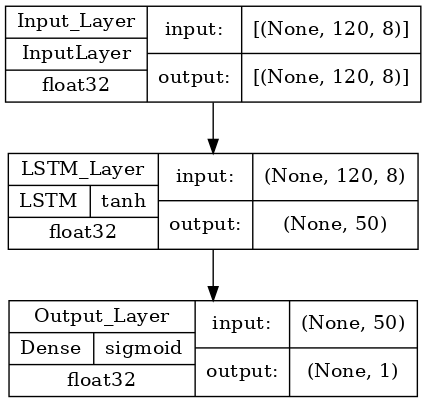

In [90]:
# Graficar el modelo
plot_model(lstm_model1, to_file=f"../notebooks/dib_modelos/lstm_model1.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

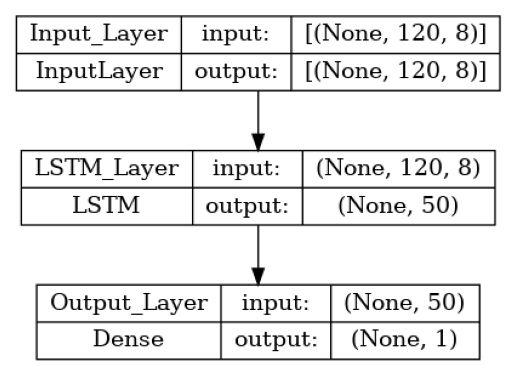

In [86]:
# Mostrar el gráfico
img = plt.imread(f"../notebooks/dib_modelos/lstm_model.png")
plt.imshow(img)
plt.axis('off')  # Para no mostrar los ejes
plt.show()

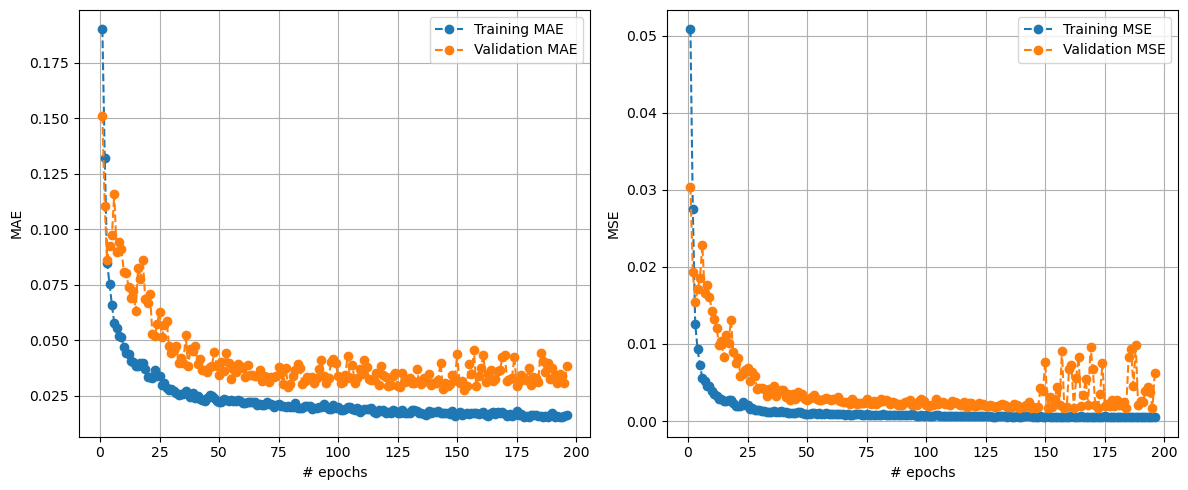

35/35 [==============================] - 5s 136ms/step - loss: 5.1257e-04 - mean_absolute_error: 0.0163 - val_loss: 0.0062 - val_mean_absolute_error: 0.0383


In [54]:
lstm_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)])

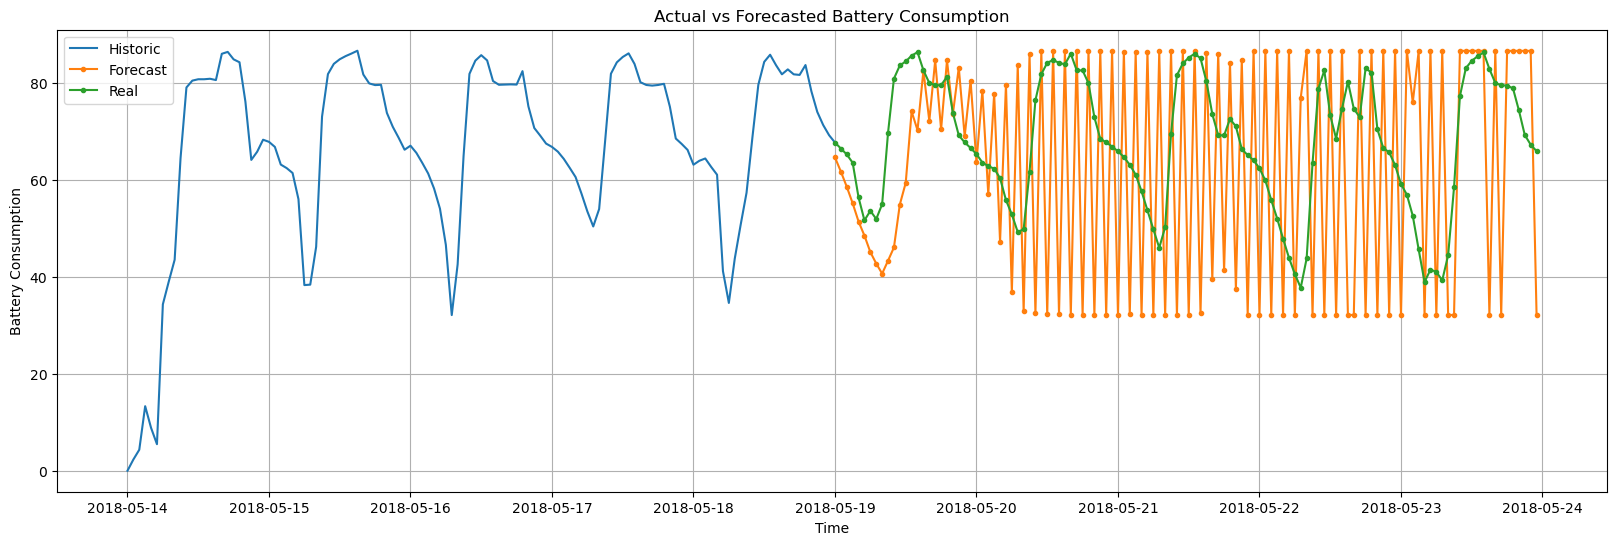

RMSE:  26.85368346944937
MSE:   721.1203158773783
MAE:   21.78154549577501


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [55]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, 
                             forecast_steps=seq_length, future_steps=future_steps, model=lstm_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble LSTM

In [56]:
# Define model
lstm_double_model = Sequential()
lstm_double_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_double_model.add(LSTM(50))
lstm_double_model.add(Dense(1, activation="sigmoid"))
lstm_double_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_double_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 120, 50)           11800     
                                                                 
 lstm_2 (LSTM)               (None, 50)                20200     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 32,051
Trainable params: 32,051
Non-trainable params: 0
_________________________________________________________________


In [78]:
# Define model lstm_model2
lstm_model2 = Sequential()

# Agregar capa de entrada con nombre explícito
lstm_model2.add(InputLayer(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), name='Input_Layer'))

# Agregar primera capa LSTM con nombre y return_sequences=True
lstm_model2.add(LSTM(50, return_sequences=True, name='LSTM_Layer_1'))

# Agregar segunda capa LSTM con nombre
lstm_model2.add(LSTM(50, name='LSTM_Layer_2'))

# Agregar capa de salida con nombre
lstm_model2.add(Dense(1, activation="sigmoid", name='Output_Layer'))

# Compilar el modelo
lstm_model2.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])

# Mostrar el resumen del modelo
lstm_model2.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_Layer_1 (LSTM)         (None, 120, 50)           11800     
                                                                 
 LSTM_Layer_2 (LSTM)         (None, 50)                20200     
                                                                 
 Output_Layer (Dense)        (None, 1)                 51        
                                                                 
Total params: 32,051
Trainable params: 32,051
Non-trainable params: 0
_________________________________________________________________


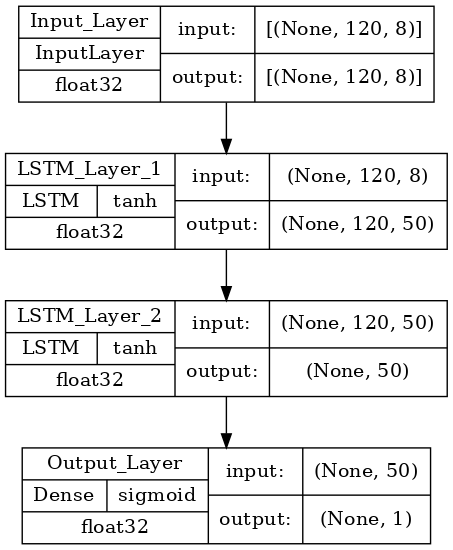

In [79]:
# Graficar el modelo
plot_model(lstm_model2, to_file=f"../notebooks/dib_modelos/lstm_model2.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

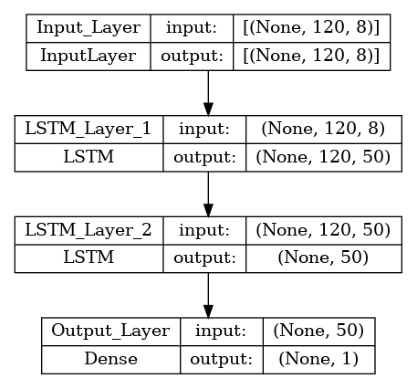

In [89]:
# Mostrar el gráfico
img = plt.imread(f"../notebooks/dib_modelos/lstm_model2.png")
plt.imshow(img)
plt.axis('off')  # Para no mostrar los ejes
plt.show()

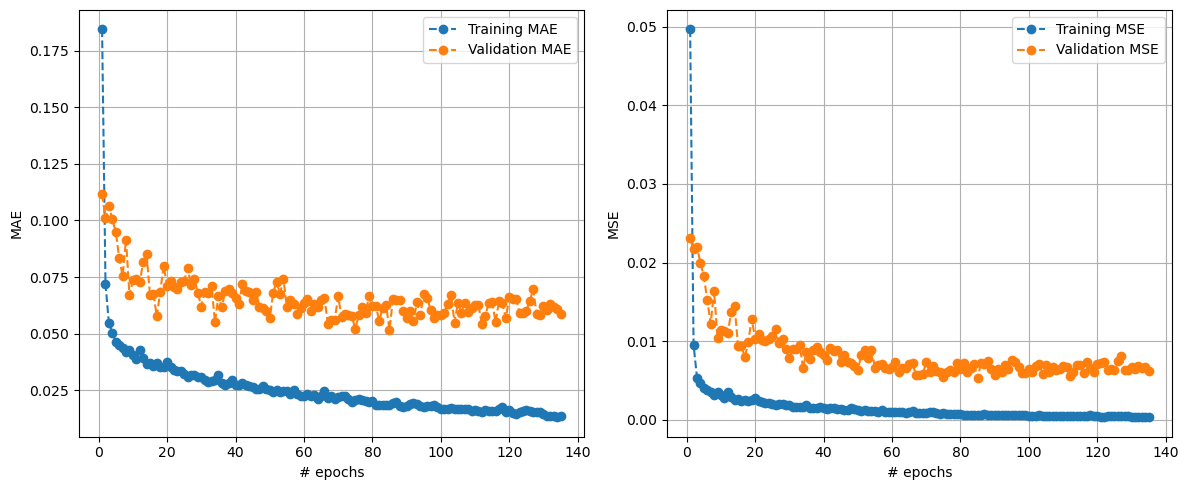

35/35 [==============================] - 1s 30ms/step - loss: 3.4437e-04 - mean_absolute_error: 0.0136 - val_loss: 0.0063 - val_mean_absolute_error: 0.0588


In [57]:
lstm_double_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

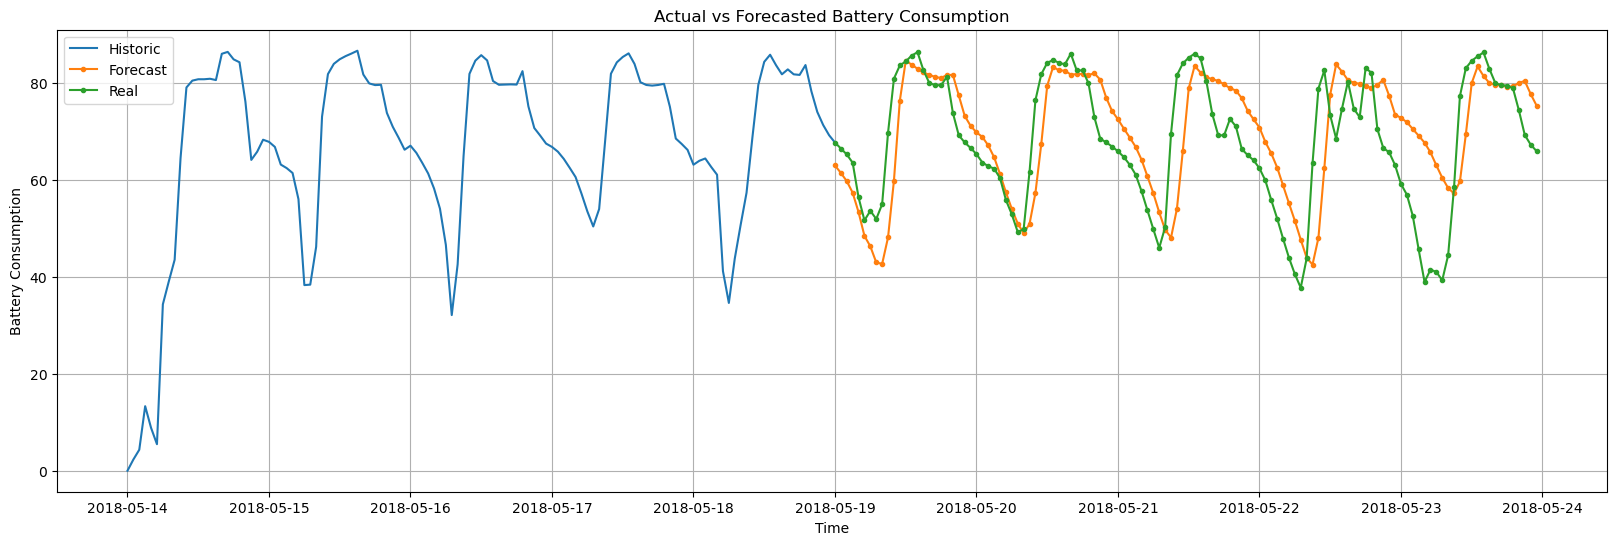

RMSE:  10.649578690627209
MSE:   113.41352628786113
MAE:   8.125388506147596


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [58]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=lstm_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo LSTM libro Jason

In [59]:
n_nodes = 50
# define model
lstm_model3 = Sequential()
lstm_model3.add(LSTM(n_nodes, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model3.add(Dense(n_nodes, activation='relu'))
lstm_model3.add(Dense(1, activation="sigmoid"))
lstm_model3.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 50)                11800     
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 14,401
Trainable params: 14,401
Non-trainable params: 0
_________________________________________________________________


In [80]:
# Define el número de nodos
n_nodes = 50

# Define el modelo lstm_model3
lstm_model3 = Sequential()

# Agregar capa de entrada con nombre explícito
lstm_model3.add(InputLayer(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), name='Input_Layer'))

# Agregar capa LSTM con nombre
lstm_model3.add(LSTM(n_nodes, activation='relu', name='LSTM_Layer'))

# Agregar capa densa con nombre
lstm_model3.add(Dense(n_nodes, activation='relu', name='Dense_Layer'))

# Agregar capa de salida con nombre
lstm_model3.add(Dense(1, activation="sigmoid", name='Output_Layer'))

# Compilar el modelo
lstm_model3.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])

# Mostrar el resumen del modelo
lstm_model3.summary()


Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_Layer (LSTM)           (None, 50)                11800     
                                                                 
 Dense_Layer (Dense)         (None, 50)                2550      
                                                                 
 Output_Layer (Dense)        (None, 1)                 51        
                                                                 
Total params: 14,401
Trainable params: 14,401
Non-trainable params: 0
_________________________________________________________________


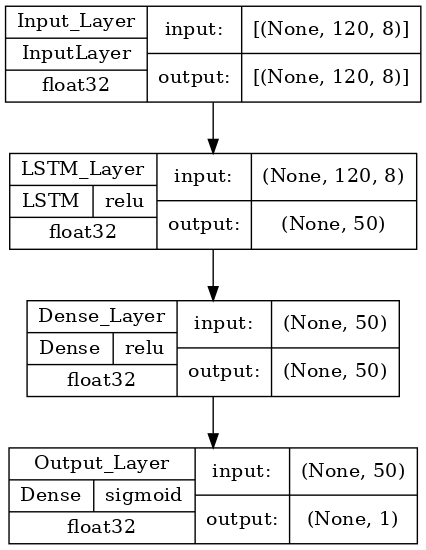

In [81]:
# Graficar el modelo
plot_model(lstm_model3, to_file=f"../notebooks/dib_modelos/lstm_model3.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

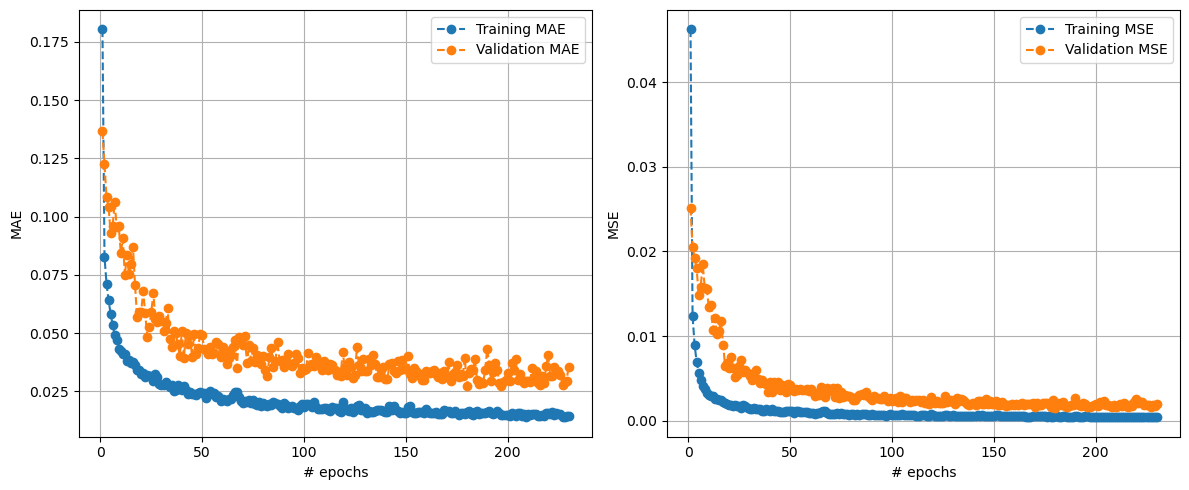

35/35 [==============================] - 7s 198ms/step - loss: 4.4879e-04 - mean_absolute_error: 0.0146 - val_loss: 0.0020 - val_mean_absolute_error: 0.0356


In [60]:
modelj.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

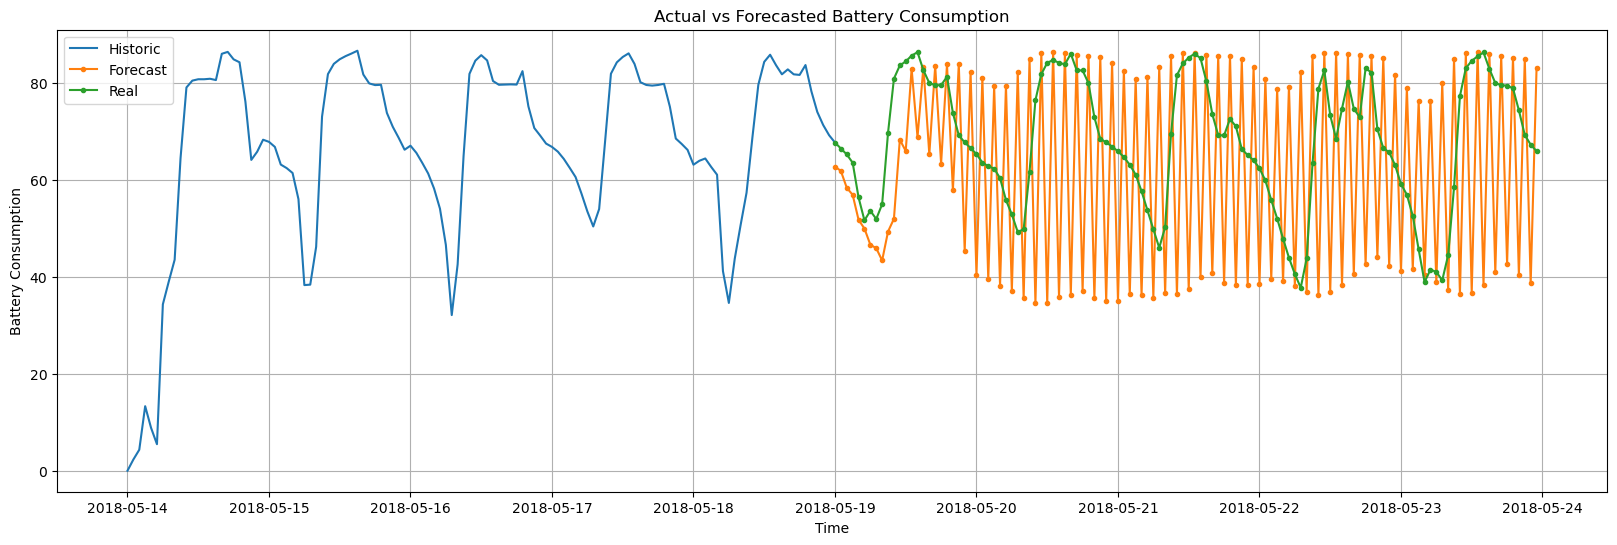

RMSE:  24.664772877930794
MSE:   608.3510211199105
MAE:   20.367123325771754


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [61]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=modelj, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo Sofisticado

In [82]:
from keras.layers import Dropout

# Crear el modelo
lstm_model4 = Sequential()
# Capa LSTM 1 (con 50 unidades)
lstm_model4.add(LSTM(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
lstm_model4.add(Dropout(0.2))
# Capa LSTM 2 (con 50 unidades)
lstm_model4.add(LSTM(50))
# Dropout para regularización
lstm_model4.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
lstm_model4.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
lstm_model4.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
lstm_model4.add(Dense(1))
lstm_model4.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_model4.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 120, 50)           11800     
                                                                 
 dropout_2 (Dropout)         (None, 120, 50)           0         
                                                                 
 lstm_2 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_8 (Dense)             (None, 64)                3264      
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 1)               

In [91]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, InputLayer

# Crear el modelo lstm_model4
lstm_model4 = Sequential()

# Agregar capa de entrada con nombre explícito
lstm_model4.add(InputLayer(input_shape=(n_steps, n_features), name='Input_Layer'))

# Capa LSTM 1 (con 50 unidades) con return_sequences=True
lstm_model4.add(LSTM(50, return_sequences=True, name='LSTM_Layer_1'))

# Dropout para regularización
lstm_model4.add(Dropout(0.2, name='Dropout_Layer_1'))

# Capa LSTM 2 (con 50 unidades)
lstm_model4.add(LSTM(50, name='LSTM_Layer_2'))

# Dropout para regularización
lstm_model4.add(Dropout(0.2, name='Dropout_Layer_2'))

# Capa densa 1 (con 64 neuronas)
lstm_model4.add(Dense(64, activation='relu', name='Dense_Layer_1'))

# Capa densa 2 (con 32 neuronas)
lstm_model4.add(Dense(32, activation='relu', name='Dense_Layer_2'))

# Capa de salida (con 1 neurona para la predicción final)
lstm_model4.add(Dense(1, activation="sigmoid", name='Output_Layer'))

# Compilar el modelo
lstm_model4.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])

# Mostrar el resumen del modelo
lstm_model4.summary()


Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_Layer_1 (LSTM)         (None, 120, 50)           11800     
                                                                 
 Dropout_Layer_1 (Dropout)   (None, 120, 50)           0         
                                                                 
 LSTM_Layer_2 (LSTM)         (None, 50)                20200     
                                                                 
 Dropout_Layer_2 (Dropout)   (None, 50)                0         
                                                                 
 Dense_Layer_1 (Dense)       (None, 64)                3264      
                                                                 
 Dense_Layer_2 (Dense)       (None, 32)                2080      
                                                                 
 Output_Layer (Dense)        (None, 1)               

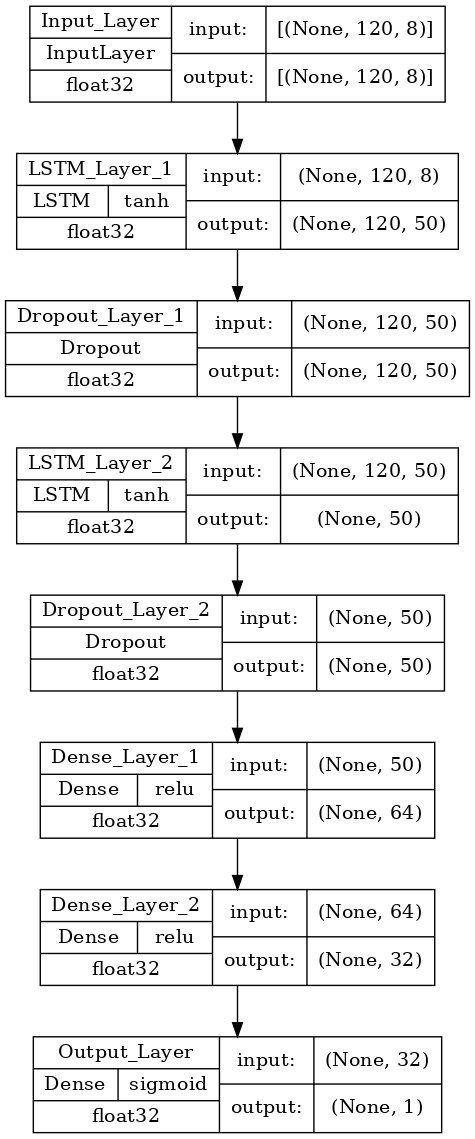

In [92]:
# Graficar el modelo
plot_model(lstm_model4, to_file=f"../notebooks/dib_modelos/lstm_model4.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

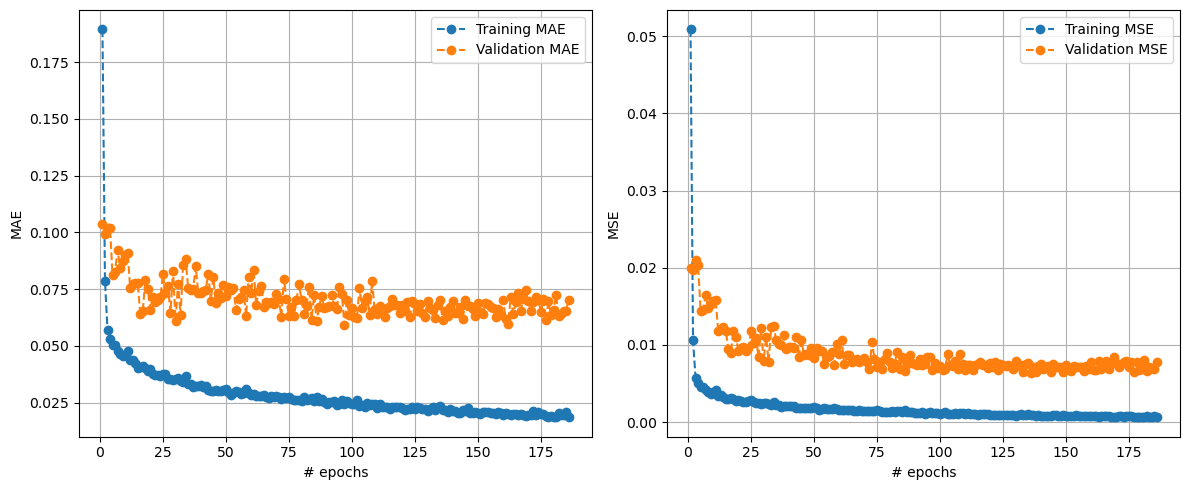

35/35 [==============================] - 5s 142ms/step - loss: 6.6212e-04 - mean_absolute_error: 0.0187 - val_loss: 0.0077 - val_mean_absolute_error: 0.0700


In [94]:
lstm_model4.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

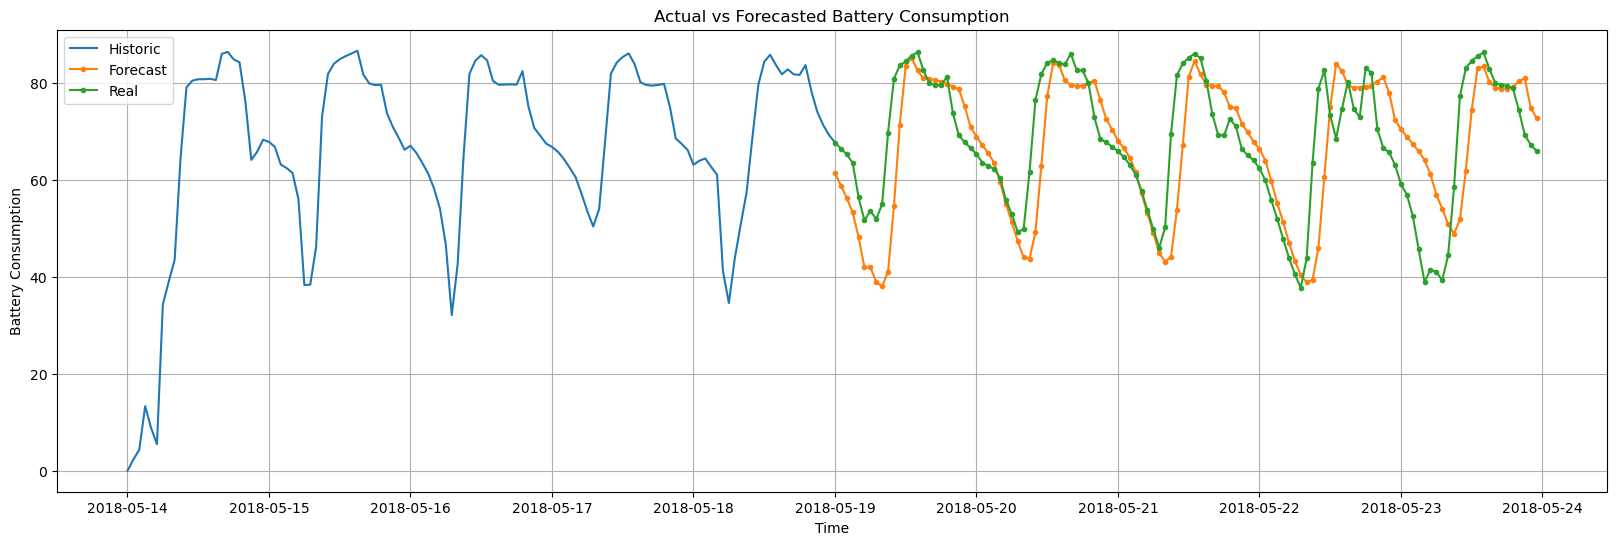

RMSE:  10.791222330396291
MSE:   116.45047938404356
MAE:   7.669083485497369


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [95]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=lstm_model4, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU

In [53]:
# Define model
gru_model1 = Sequential()
gru_model1.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_model1.add(Dense(1, activation='sigmoid'))
gru_model1.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model1.summary()

2024-11-27 17:40:10.315403: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-11-27 17:40:10.315464: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: hp-elite
2024-11-27 17:40:10.315481: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: hp-elite
2024-11-27 17:40:10.315705: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 520.61.5
2024-11-27 17:40:10.315754: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 520.61.5
2024-11-27 17:40:10.315769: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 520.61.5
2024-11-27 17:40:10.317812: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Lib

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 50)                9000      
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 9,051
Trainable params: 9,051
Non-trainable params: 0
_________________________________________________________________


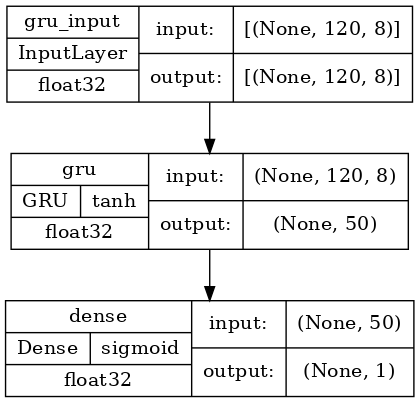

In [85]:
# Graficar el modelo
plot_model(gru_model1, to_file=f"../notebooks/dib_modelos/gru_model1.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

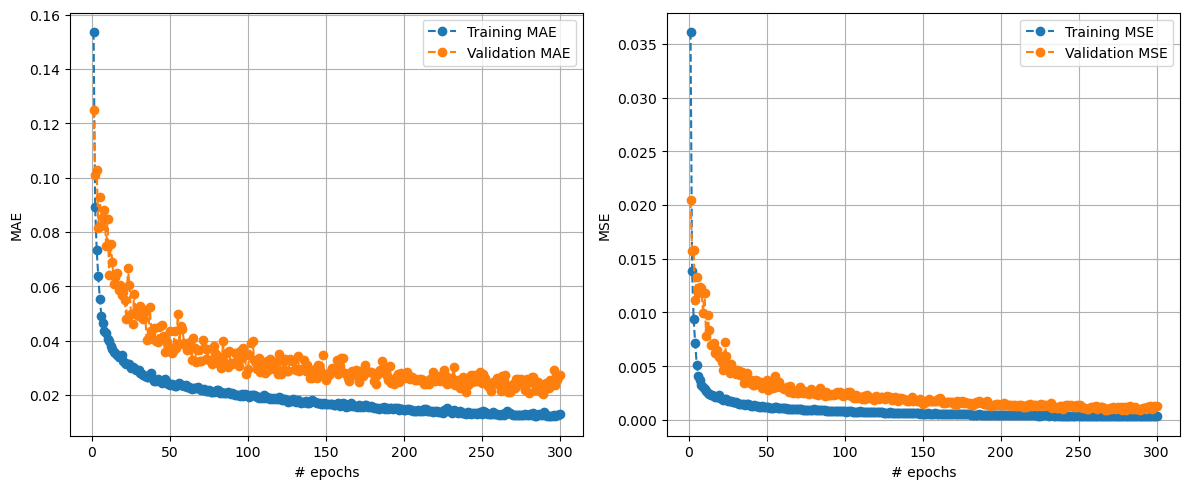

35/35 [==============================] - 1s 20ms/step - loss: 3.4473e-04 - mean_absolute_error: 0.0130 - val_loss: 0.0013 - val_mean_absolute_error: 0.0272


In [66]:
gru_model.fit(X_train_seq,
              y_train_seq,
              epochs=300,
              batch_size=72,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[
              PlotLearning(),
              EarlyStopping(monitor='val_loss', patience=50)])

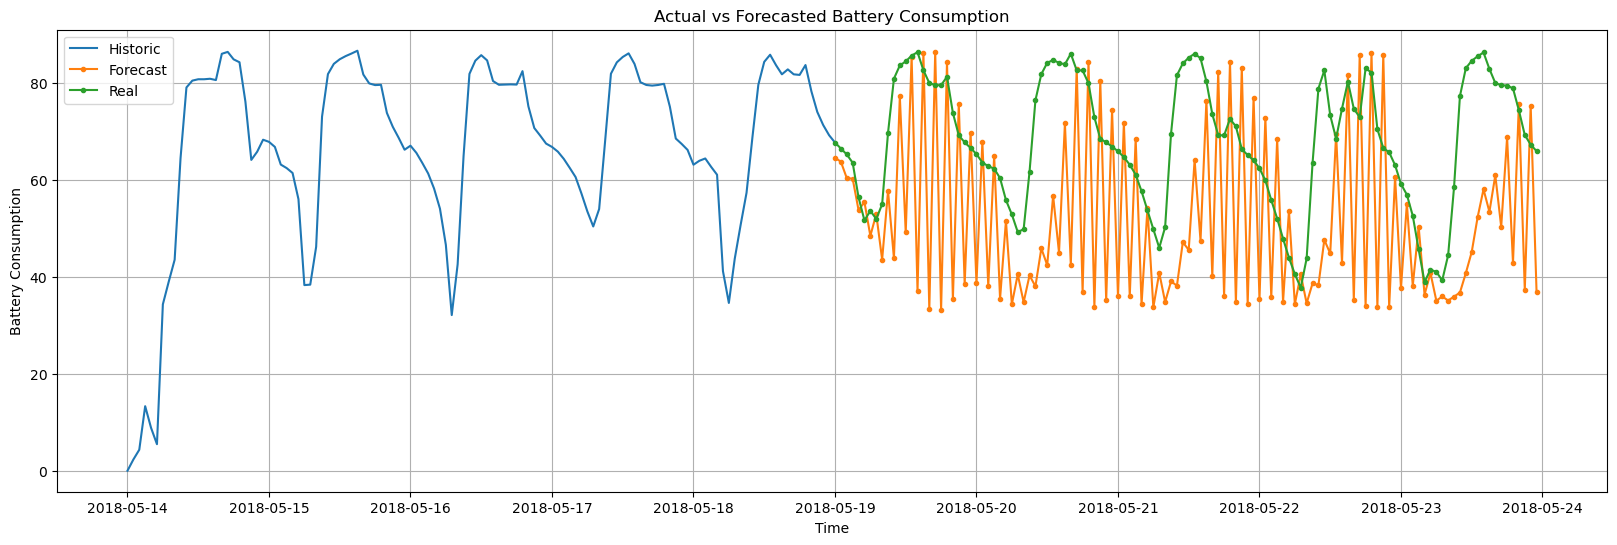

RMSE:  24.581575739208542
MSE:   604.2538658224461
MAE:   19.728944392734103


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [67]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble GRU

In [55]:
# Define model
gru_model2 = Sequential()
gru_model2.add(GRU(units=50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_model2.add(GRU(units=50))
gru_model2.add(Dense(1, activation='sigmoid'))
gru_model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 (None, 120, 50)           9000      
                                                                 
 gru_2 (GRU)                 (None, 50)                15300     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 24,351
Trainable params: 24,351
Non-trainable params: 0
_________________________________________________________________


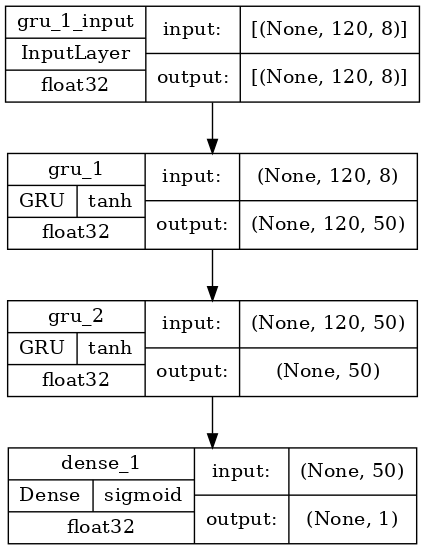

In [86]:
# Graficar el modelo
plot_model(gru_model2, to_file=f"../notebooks/dib_modelos/gru_model2.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

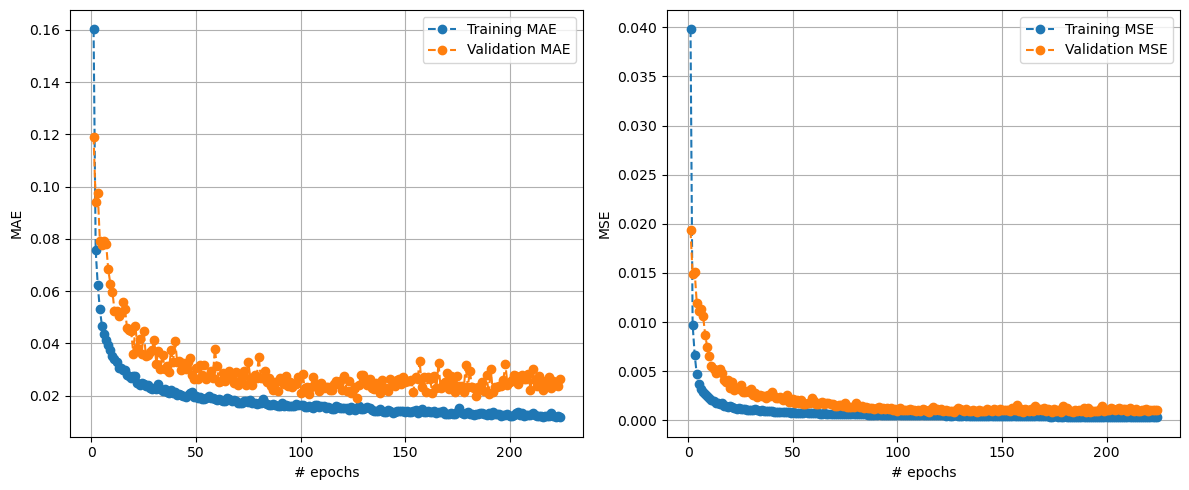

35/35 [==============================] - 1s 26ms/step - loss: 3.1316e-04 - mean_absolute_error: 0.0118 - val_loss: 0.0011 - val_mean_absolute_error: 0.0262


In [69]:
gru_double_model.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

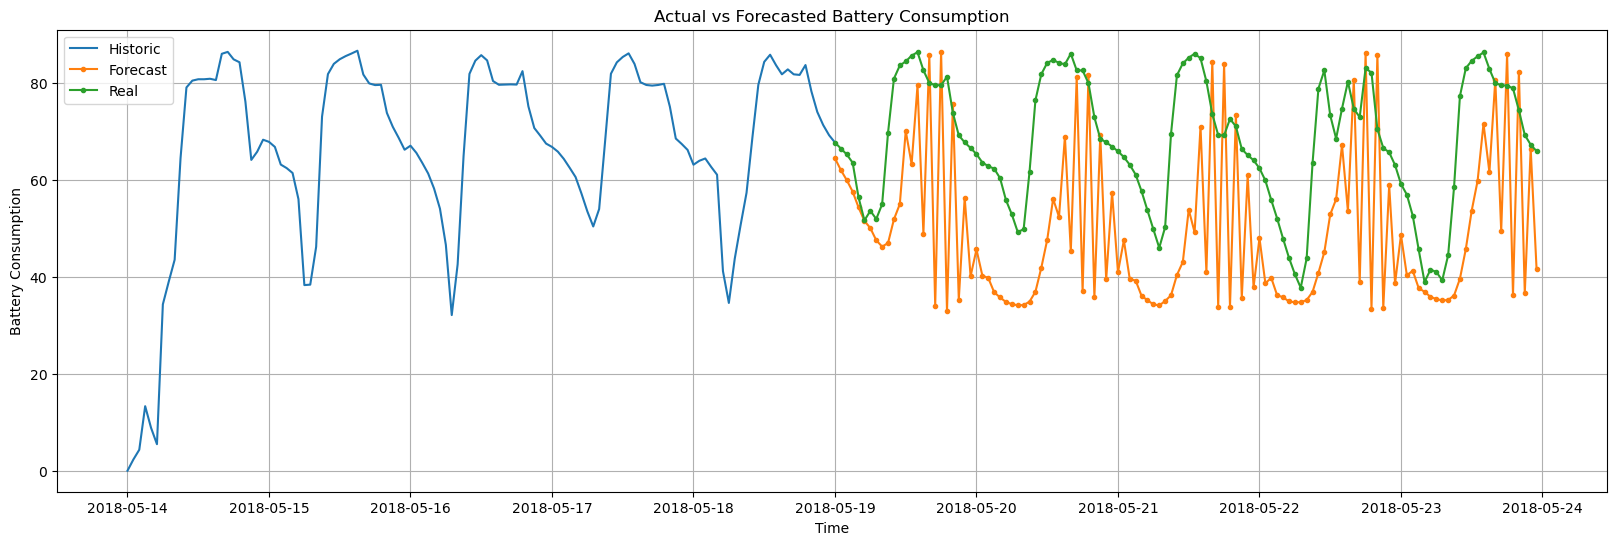

RMSE:  23.699404984588295
MSE:   561.6617966235285
MAE:   19.749860655042863


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [70]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

In [71]:
#compare_model_performance(test=test_dataset, seq_length=seq_length, future_steps=seq_length, models=[('gru_model', gru_model), ('gru_double_model', 
#                         gru_double_model)], scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU libro Jason

In [58]:
n_nodes = 50
# Define model
gru_model3 = Sequential()
gru_model3.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_model3.add(Dense(n_nodes, activation='relu'))
gru_model3.add(Dense(1, activation='sigmoid'))
gru_model3.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model3.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_4 (GRU)                 (None, 50)                9000      
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 11,601
Trainable params: 11,601
Non-trainable params: 0
_________________________________________________________________


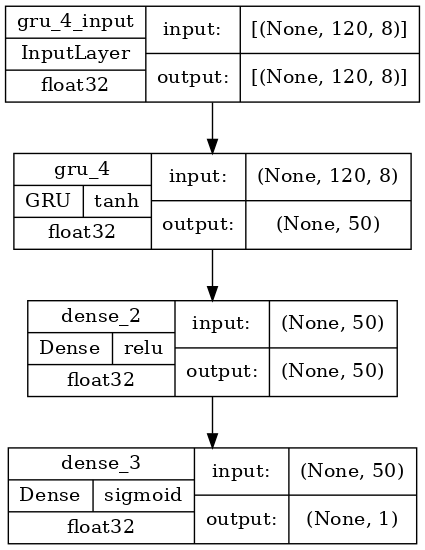

In [87]:
# Graficar el modelo
plot_model(gru_model3, to_file=f"../notebooks/dib_modelos/gru_model3.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

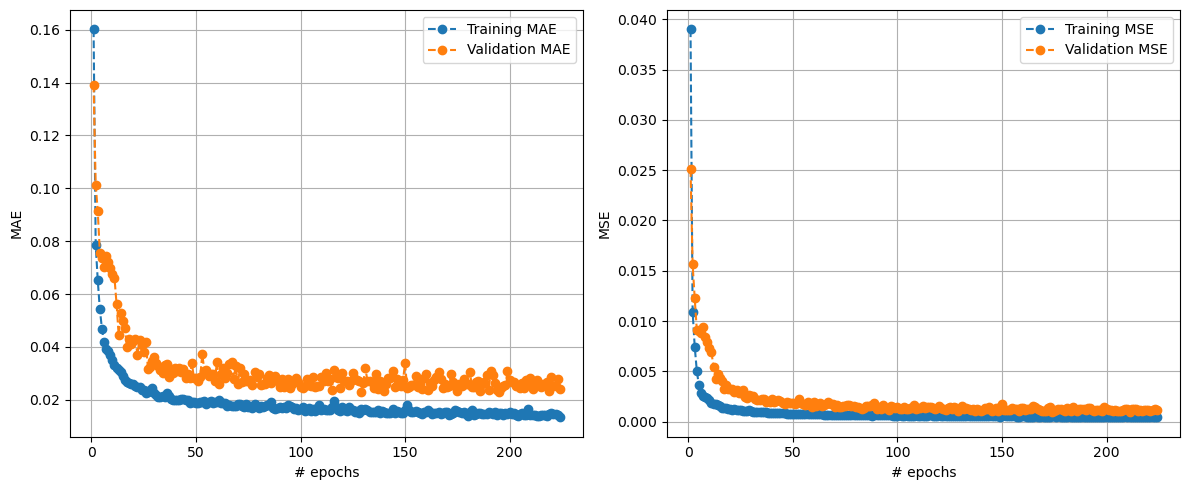

35/35 [==============================] - 1s 18ms/step - loss: 4.3618e-04 - mean_absolute_error: 0.0134 - val_loss: 0.0011 - val_mean_absolute_error: 0.0242


In [73]:
gru_modelj.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

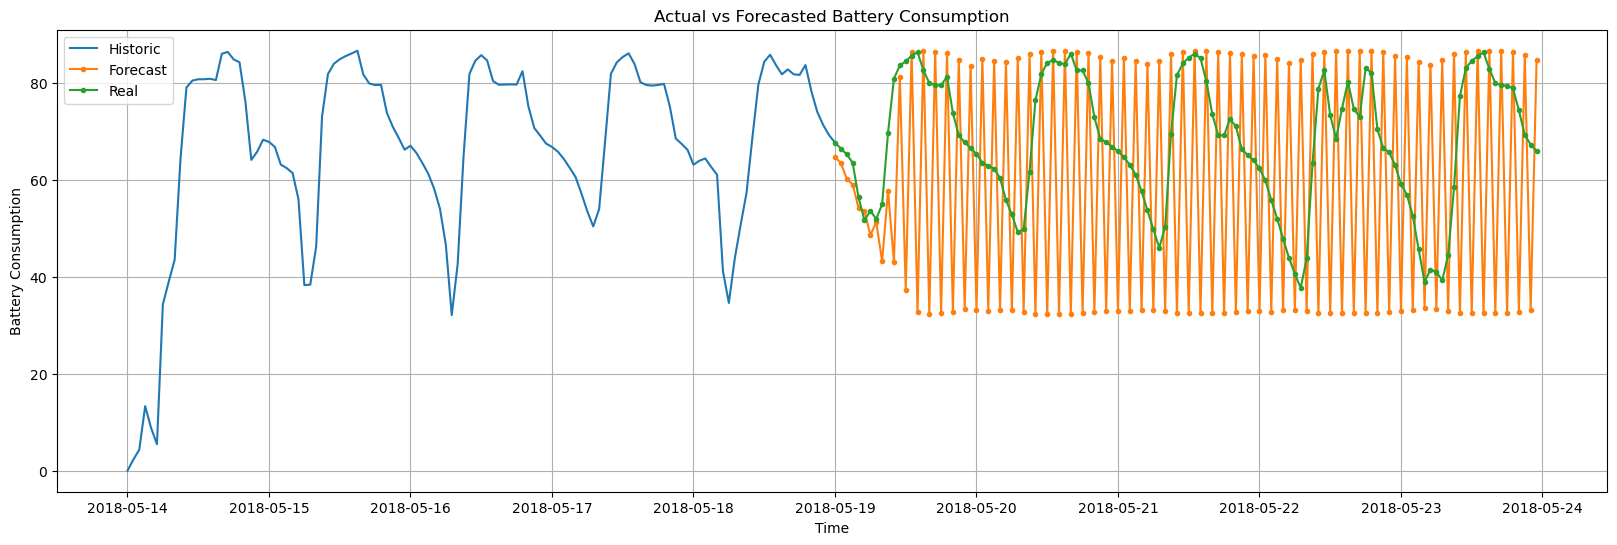

RMSE:  29.634431757365995
MSE:   878.1995455819822
MAE:   24.56164035076565


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [74]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_modelj, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU Sofisticado

In [96]:
# Crear el modelo
gru_model4 = Sequential()
# Capa GRU 1 (con 50 unidades)
gru_model4.add(GRU(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
gru_model4.add(Dropout(0.2))
# Capa GRU 2 (con 50 unidades)
gru_model4.add(GRU(50))
# Dropout para regularización
gru_model4.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
gru_model4.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
gru_model4.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
gru_model4.add(Dense(1, activation='sigmoid'))
gru_model4.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
gru_model4.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_8 (GRU)                 (None, 120, 50)           9000      
                                                                 
 dropout_4 (Dropout)         (None, 120, 50)           0         
                                                                 
 gru_9 (GRU)                 (None, 50)                15300     
                                                                 
 dropout_5 (Dropout)         (None, 50)                0         
                                                                 
 dense_11 (Dense)            (None, 64)                3264      
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 1)               

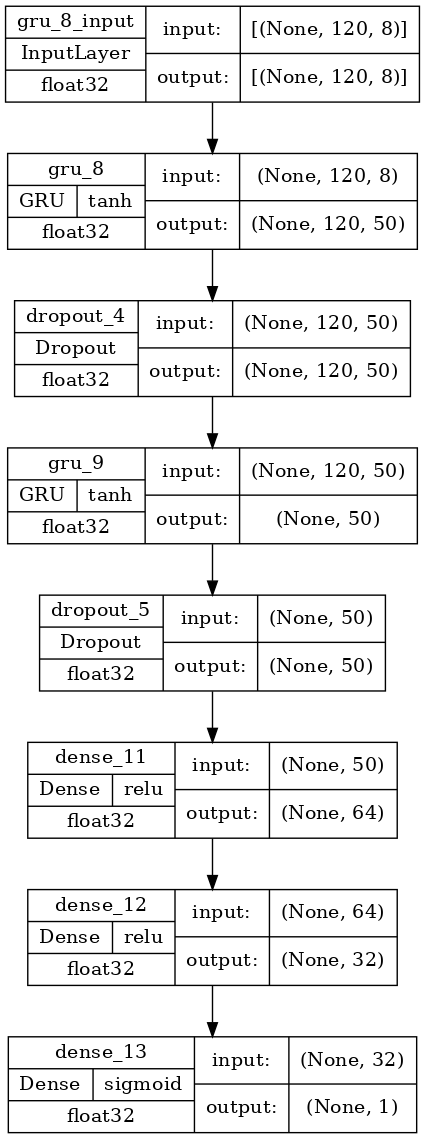

In [97]:
# Graficar el modelo
plot_model(gru_model4, to_file=f"../notebooks/dib_modelos/gru_model4.png", 
           show_shapes=True, 
           show_dtype= True,
           show_layer_names=True,
           rankdir= "TB",
           expand_nested=True,
           dpi=100,
           show_layer_activations=True)

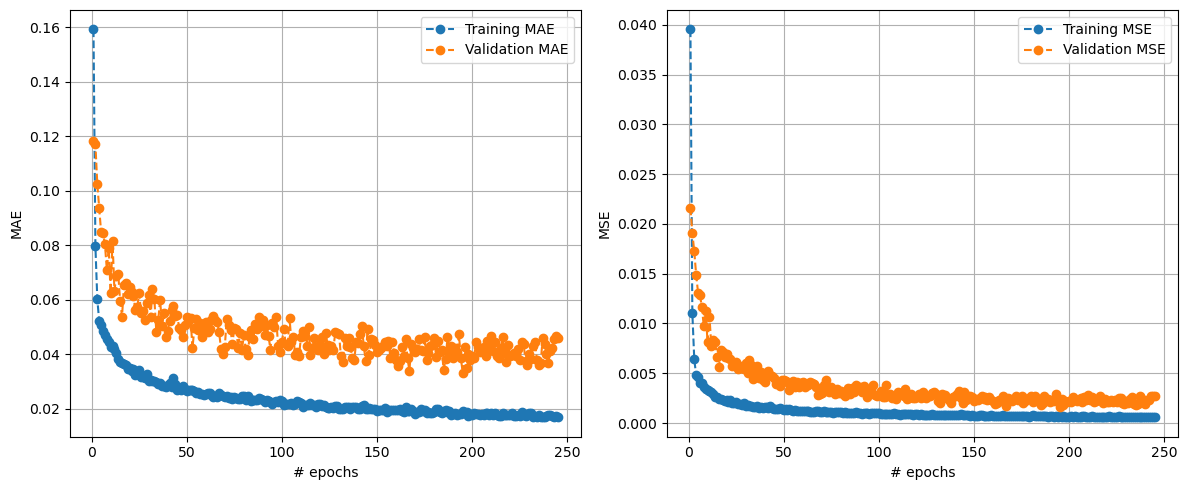

35/35 [==============================] - 5s 132ms/step - loss: 5.7241e-04 - mean_absolute_error: 0.0168 - val_loss: 0.0027 - val_mean_absolute_error: 0.0458


In [99]:
gru_model4.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

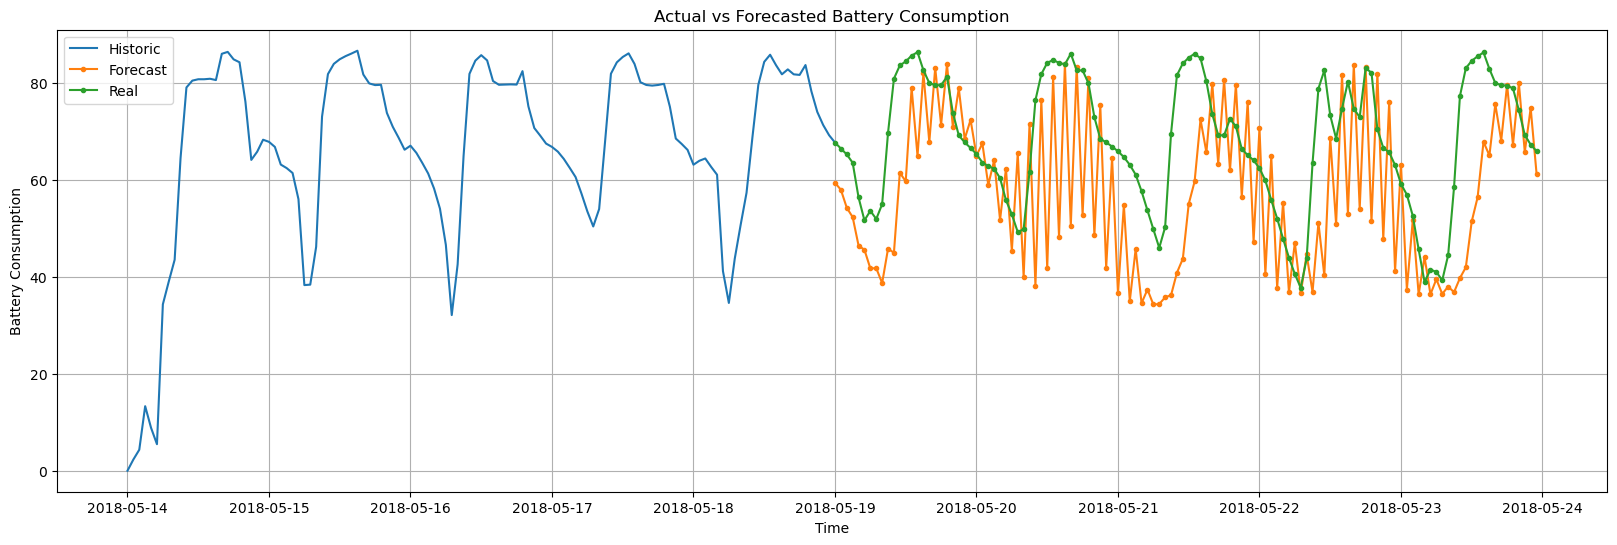

RMSE:  18.039045222769733
MSE:   325.40715254913147
MAE:   14.057664013756646


(                  fecha  temperature  pressure    battery  air_humidity  \
 0   2018-05-14 00:00:00    10.670000  987.8400   0.020000     42.950000   
 1   2018-05-14 01:00:00    10.010000  987.8450   2.335000     41.695000   
 2   2018-05-14 02:00:00     9.293333  987.4900   4.346667     45.693333   
 3   2018-05-14 03:00:00    11.330000  986.7550  13.330000     45.570000   
 4   2018-05-14 04:00:00    13.295000  986.5900   8.860000     43.707500   
 ..                  ...          ...       ...        ...           ...   
 116 2018-05-18 20:00:00    22.767500  985.0825  78.260000     39.902500   
 117 2018-05-18 21:00:00    18.635000  985.7175  74.012500     43.607500   
 118 2018-05-18 22:00:00    16.402500  986.2725  71.310000     47.922500   
 119 2018-05-18 23:00:00    14.625000  986.6075  69.212500     50.940000   
 120 2018-05-19 00:00:00    13.660000  986.4725  67.700000     56.370000   
 
      wind_speed  irradiancia  minutos_dia  hora  
 0      2.410000          0.0      

In [100]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length, 
                             future_steps=future_steps, model=gru_model4, scaler_x=scaler_x, scaler_y=scaler_y)